# Customer Lifetime Value (LTV) Prediction

##  Introduction:

I worked on building a Customer Lifetime Value (LTV) prediction model to help the company better understand customer behavior and support targeted marketing strategies.

* The main objective of this project was to:
    Predict the future value of customers based on their historical purchase behavior
    Identify high value customers
    Support marketing and retention decision making
    
    
* The tools used in this project were:
    Python (Pandas, Scikit-learn, XGBoost) for data processing and modeling
    Excel for result validation and summary reporting

##  Dataset Overview:

### From your dataset:
1. Order Information
    order_id
    order_status
    order_purchase_timestamp
    order_approved_at
    order_delivered_customer_date
    order_estimated_delivery_date
    
2.  Product & Payment
    price
    freight_value
    order_item_id
    
3. Customer Info
    customer_id
    customer_unique_id
    customer_city
    customer_state
    
* The data represents transactional sales information from a retail business.

## Business Problem:

* In retail and e-commerce businesses, not all customers contribute equally to revenue. 
    Focus marketing efforts on profitable customers
    
    Improve customer retention strategies
    
    Allocate promotional budgets efficiently
    
    Therefore, predicting Customer Lifetime Value helps in making data driven marketing decisions.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
customer = pd.read_csv('olist_customers_dataset.csv', sep = ',')
order_items =  pd.read_csv('olist_order_items_dataset.csv', sep = ',')
orders = pd.read_csv('olist_orders_dataset.csv', sep = ',')

In [3]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [4]:
customer.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [5]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [6]:
data = orders.merge(order_items, on = 'order_id', how = 'left')

data = data.merge(customer, on = 'customer_id', how = 'left')

In [7]:
data.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


In [8]:
data.shape

(113425, 18)

In [9]:
data.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'customer_unique_id',
       'customer_zip_code_prefix', 'customer_city', 'customer_state'],
      dtype='object')

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 113425 entries, 0 to 113424
Data columns (total 18 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       113425 non-null  object 
 1   customer_id                    113425 non-null  object 
 2   order_status                   113425 non-null  object 
 3   order_purchase_timestamp       113425 non-null  object 
 4   order_approved_at              113264 non-null  object 
 5   order_delivered_carrier_date   111457 non-null  object 
 6   order_delivered_customer_date  110196 non-null  object 
 7   order_estimated_delivery_date  113425 non-null  object 
 8   order_item_id                  112650 non-null  float64
 9   product_id                     112650 non-null  object 
 10  seller_id                      112650 non-null  object 
 11  shipping_limit_date            112650 non-null  object 
 12  price                         

In [11]:
data.describe()

,order_item_id,price,freight_value,customer_zip_code_prefix
count,112650.000000,112650.000000,112650.000000,113425.000000
mean,1.197834,120.653739,19.990320,35102.472965
std,0.705124,183.633928,15.806405,29864.919733
min,1.000000,0.850000,0.000000,1003.000000
25%,1.000000,39.900000,13.080000,11250.000000
50%,1.000000,74.990000,16.260000,24320.000000
75%,1.000000,134.900000,21.150000,59020.000000
max,21.000000,6735.000000,409.680000,99990.000000


In [12]:
data.describe(include = 'object')

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,product_id,seller_id,shipping_limit_date,customer_unique_id,customer_city,customer_state
count,113425,113425,113425,113425,113264,111457,110196,113425,112650,112650,112650,113425,113425,113425
unique,99441,99441,8,98875,90733,81018,95664,459,32951,3095,93318,96096,4119,27
top,8272b63d03f5f79c56e9e4120aec44ef,fc3d1daec319d62d49bfb5e1f83123e9,delivered,2017-07-16 18:19:25,2018-02-24 03:20:27,2018-05-09 15:48:00,2017-07-31 18:03:02,2017-12-20 00:00:00,aca2eb7d00ea1a7b8ebd4e68314663af,6560211a19b47992c3666cc44a7e94c0,2017-07-21 18:25:23,c8460e4251689ba205045f3ea17884a1,sao paulo,SP
freq,21,21,110197,21,23,48,21,611,527,2033,21,24,17946,47820


In [13]:
data.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 161
order_delivered_carrier_date     1968
order_delivered_customer_date    3229
order_estimated_delivery_date       0
order_item_id                     775
product_id                        775
seller_id                         775
shipping_limit_date               775
price                             775
freight_value                     775
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
dtype: int64

##  Feature Engineering:

* The following steps were performed:
        Removed missing values
        Converted date columns to datetime format
        Converted revenue columns to numeric
        Checked for duplicate records

* Features were created using historical purchase data.

1. Recency
Number of days since last purchase.

2. Frequency
Number of unique orders placed by the customer.

3. Monetary Value (Total Spend)
Total revenue generated by the customer.

4. Average Order Value (AOV)
Average spending per order.

These features were aggregated using groupby operations in Pandas.

In [14]:
data.duplicated().sum()

0

In [15]:
data = data.drop_duplicates()

In [16]:
data.dropna(inplace = True)

In [17]:
col = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'shipping_limit_date']

data[col] = data[col].apply(pd.to_datetime)

In [18]:
col = ['price', 'freight_value']

data[col] = data[col].apply(pd.to_numeric, errors = 'coerce')

In [19]:
data['total_value'] = data['price'] + data['freight_value']

In [20]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 110180 entries, 0 to 113424
Data columns (total 19 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       110180 non-null  object        
 1   customer_id                    110180 non-null  object        
 2   order_status                   110180 non-null  object        
 3   order_purchase_timestamp       110180 non-null  datetime64[ns]
 4   order_approved_at              110180 non-null  datetime64[ns]
 5   order_delivered_carrier_date   110180 non-null  datetime64[ns]
 6   order_delivered_customer_date  110180 non-null  datetime64[ns]
 7   order_estimated_delivery_date  110180 non-null  datetime64[ns]
 8   order_item_id                  110180 non-null  float64       
 9   product_id                     110180 non-null  object        
 10  seller_id                      110180 non-null  object        
 11  

##  Creating a RFM Features:


In [21]:
# Recency:

date = data['order_purchase_timestamp'].max() + pd.Timedelta(days = 1)

recency = data.groupby('customer_unique_id')['order_purchase_timestamp'].max().reset_index()
recency['recency'] = (date - recency['order_purchase_timestamp']).dt.days

recency

,customer_unique_id,order_purchase_timestamp,recency
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,112
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,115
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,537
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,321
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,288
...,...,...,...
93337,fffcf5a5ff07b0908bd4e2dbc735a684,2017-06-08 21:00:36,447
93338,fffea47cd6d3cc0a88bd621562a9d061,2017-12-10 20:07:56,262
93339,ffff371b4d645b6ecea244b27531430a,2017-02-07 15:49:16,568
93340,ffff5962728ec6157033ef9805bacc48,2018-05-02 15:17:41,119


In [27]:
# Frequency:

frequency = data.groupby('customer_unique_id')['order_id'].nunique().reset_index()
frequency.rename(columns = {'order_id': 'frequency'}, inplace = True)

frequency

,customer_unique_id,frequency
0,0000366f3b9a7992bf8c76cfdf3221e2,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1
2,0000f46a3911fa3c0805444483337064,1
3,0000f6ccb0745a6a4b88665a16c9f078,1
4,0004aac84e0df4da2b147fca70cf8255,1
...,...,...
93337,fffcf5a5ff07b0908bd4e2dbc735a684,1
93338,fffea47cd6d3cc0a88bd621562a9d061,1
93339,ffff371b4d645b6ecea244b27531430a,1
93340,ffff5962728ec6157033ef9805bacc48,1


In [29]:
# Monetary (Total Spend):
monetary = data.groupby('customer_unique_id')['total_value'].sum().reset_index()
monetary.rename(columns = {'total_value': 'total_spend'}, inplace = True)

# Average Order Value (AOV):
aov = data.groupby('customer_unique_id')['total_value'].mean().reset_index()
aov.rename(columns = {'total_value': 'aov'}, inplace = True)

# Future LTV:
ltv = data.groupby('customer_unique_id')['total_value'].sum().reset_index()
ltv.rename(columns = {'total_value': 'LTV'}, inplace = True)

In [31]:
cutoff_date = data['order_purchase_timestamp'].quantile(0.75)

historical = data[data['order_purchase_timestamp'] <= cutoff_date]
future = data[data['order_purchase_timestamp'] > cutoff_date]

In [33]:
customer_data = recency.merge(frequency, on = 'customer_unique_id')
customer_data = customer_data.merge(monetary, on = 'customer_unique_id')
customer_data = customer_data.merge(aov, on = 'customer_unique_id')

customer_data = customer_data.merge(ltv, on = 'customer_unique_id', how = 'inner')

customer_data.head()

,customer_unique_id,order_purchase_timestamp,recency,frequency,total_spend,aov,LTV
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,112,1,141.90,141.90,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,115,1,27.19,27.19,27.19
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,537,1,86.22,86.22,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,321,1,43.62,43.62,43.62
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,288,1,196.89,196.89,196.89


The total revenue generated by the customer in a future time period.
Historical purchase behavior was used as input features, while future revenue was used as the prediction target.
This approach ensures that the model predicts future customer value instead of simply learning past totals.

## Model:

In [36]:
from sklearn.model_selection import train_test_split

X = customer_data[['recency', 'frequency', 'aov', 'total_spend']]
y = customer_data['LTV']

The regression model was tested:

        XGBoost Regressor
        
The dataset was split into:
        
        80% Training data
        20% Testing data

The model performance was evaluated using:
        
        MAE (Mean Absolute Error)
        RMSE (Root Mean Squared Error)


## Model Evaluation:

In [54]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
 
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = XGBRegressor(n_estimators = 200, max_depth = 4, learning_rate = 0.1, random_state = 42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print('MAE:', round(mean_absolute_error(y_test, y_pred), 2))
print('RMSE:', round(np.sqrt(mean_squared_error(y_test, y_pred)), 2))

MAE: 4.22
RMSE: 102.59


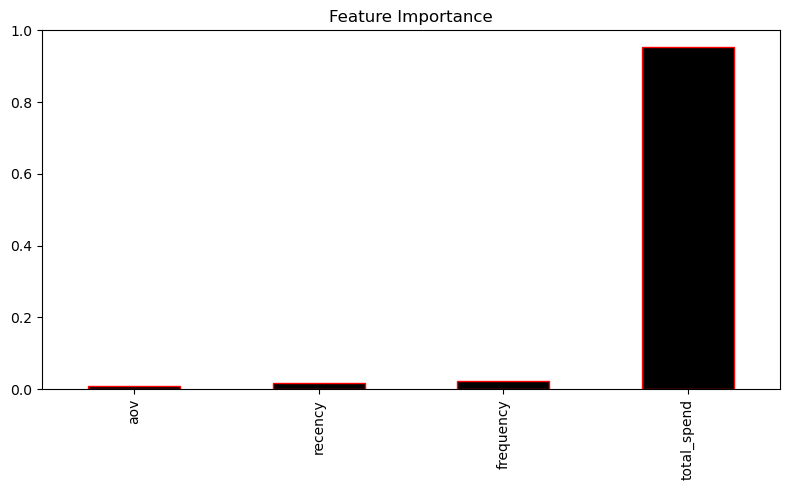

In [55]:
importance = pd.Series(model.feature_importances_, index = X.columns)

plt.figure(figsize=(8,5))
importance.sort_values().plot(kind = 'bar', color = 'black', edgecolor = 'red')
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

In [57]:
customer_data['Predicted_LTV'] = model.predict(X)

customer_data['Segment'] = pd.qcut(customer_data['Predicted_LTV'], q = 3, labels = ['Low', 'Medium', 'High'])

In [58]:
customer_data

,customer_unique_id,order_purchase_timestamp,recency,frequency,total_spend,aov,LTV,Predicted_LTV,Segment
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,112,1,141.90,141.90,141.90,142.490036,Medium
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,115,1,27.19,27.19,27.19,27.261406,Low
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,537,1,86.22,86.22,86.22,85.391205,Medium
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,321,1,43.62,43.62,43.62,43.185600,Low
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,288,1,196.89,196.89,196.89,196.651489,High
...,...,...,...,...,...,...,...,...,...
93337,fffcf5a5ff07b0908bd4e2dbc735a684,2017-06-08 21:00:36,447,1,2067.42,1033.71,2067.42,2432.155518,High
93338,fffea47cd6d3cc0a88bd621562a9d061,2017-12-10 20:07:56,262,1,84.58,84.58,84.58,84.506134,Medium
93339,ffff371b4d645b6ecea244b27531430a,2017-02-07 15:49:16,568,1,112.46,112.46,112.46,112.678749,Medium
93340,ffff5962728ec6157033ef9805bacc48,2018-05-02 15:17:41,119,1,133.69,133.69,133.69,132.313324,Medium


## Key Insights:

Customers with high purchase frequency contribute significantly to revenue.
Recently active customers are more likely to generate future revenue.
A small percentage of customers contribute to a large portion of predicted LTV.
Predictive modeling can help prioritize marketing investment efficiently.

## Conclusion:

This project demonstrated how machine learning can be used to predict Customer Lifetime Value and support strategic marketing decisions.
By identifying the customers in advance, the company can improve retention, increase profitability, and optimize marketing spend.
The project analysed the predictive analytics and practical implementation of machine learning in a business environment.